<a href="https://colab.research.google.com/github/Maverick-0508/Kyama-ML-Project/blob/main/KYAMA_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Link your Google Drive to keep your dataset saved permanently
from google.colab import drive
drive.mount('/content/drive')

# Verify that your dataset is visible
import os
project_path = '/content/drive/MyDrive/KYAMA_ML_Project/data/'
print("Your available data files:", os.listdir(project_path))

Mounted at /content/drive
Your available data files: []


In [ ]:
import os

# Define the path to your data folder
folder_path = '/content/drive/MyDrive/KYAMA_ML_Project/data/'

# List all files inside that folder
try:
    files = os.listdir(folder_path)
    print("✅ Connection successful! Your files are:")
    for file in files:
        print(f" - {file}")
except FileNotFoundError:
    print("❌ Path not found. Double-check your folder names in Google Drive.")
    print("Note: Google Drive is case-sensitive (e.g., 'data' is different from 'Data').")

✅ Connection successful! Your files are:
 - financial-inclusion-in-africa


In [ ]:
import os
import pandas as pd

# Define the exact folder path we discovered
folder_path = '/content/drive/MyDrive/KYAMA_ML_Project/data/Financial-inclusion-in-africa/'

try:
    # 1. Look inside the directory
    internal_contents = os.listdir(folder_path)
    print("📂 Files found inside the directory:")
    for file in internal_contents:
        print(f"  - {file}")

    # 2. Find any file ending with .csv
    csv_files = [f for f in internal_contents if f.lower().endswith('.csv')]

    if len(csv_files) > 0:
        # Pick the first CSV found
        chosen_csv = csv_files[0]
        full_csv_path = os.path.join(folder_path, chosen_csv)
        print(f"\n🎯 Loading CSV file: '{chosen_csv}'")

        # Load into pandas DataFrame
        df = pd.read_csv(full_csv_path)
        print("✅ DataFrame successfully created!")
        print(f"Data Dimensions: {df.shape[0]} rows, {df.shape[1]} columns.\n")

        # Preview the data structure
        print("--- Columns Available ---")
        print(list(df.columns))
        print("\n--- First 3 Rows ---")
        display(df.head(3))
    else:
        print("\n❌ No .csv files found inside that folder. Please check if they are zipped (.zip).")

except Exception as e:
    print(f"❌ Failed to explore directory: {e}")


📂 Files found inside the directory:
  - VariableDefinitions.csv
  - Train.csv
  - Test.csv

🎯 Loading CSV file: 'VariableDefinitions.csv'
✅ DataFrame successfully created!
Data Dimensions: 12 rows, 2 columns.

--- Columns Available ---
['Variable Definitions', 'Unnamed: 1']

--- First 3 Rows ---


,Variable Definitions,Unnamed: 1
0,country,Country interviewee is in.
1,year,Year survey was done in.
2,uniqueid,Unique identifier for each interviewee


In [ ]:
import os
import pandas as pd

# Define the folder path
folder_path = '/content/drive/MyDrive/KYAMA_ML_Project/data/Financial-inclusion-in-africa/'
train_csv_path = os.path.join(folder_path, 'Train.csv')

# Load the actual training data
df = pd.read_csv(train_csv_path)

print("✅ Main project data loaded successfully!")
print(f"Data Dimensions: {df.shape[0]} rows (respondents), {df.shape[1]} columns.\n")

print("--- Columns in your Dataset ---")
print(list(df.columns))

print("\n--- Preview of the Data ---")
display(df.head(3))


✅ Main project data loaded successfully!
Data Dimensions: 23524 rows (respondents), 13 columns.

--- Columns in your Dataset ---
['country', 'year', 'uniqueid', 'bank_account', 'location_type', 'cellphone_access', 'household_size', 'age_of_respondent', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']

--- Preview of the Data ---


,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# ==========================================
# STEP 1: FILTERING & CLEANING (KENYA SCOPE)
# ==========================================
# Filter for Kenya to strictly match your concept note focus
df_kenya = df[df['country'] == 'Kenya'].copy()
print(f"📊 Filtered dataset to Kenya rows. New Shape: {df_kenya.shape[0]} rows.")

# Drop high-cardinality, non-predictive operational IDs
df_kenya = df_kenya.drop(columns=['country', 'uniqueid'])

# ==========================================
# STEP 2: CATEGORICAL ENCODING
# ==========================================
# Convert binary and text columns into machine-readable numeric formats
label_encoders = {}
categorical_cols = ['bank_account', 'location_type', 'cellphone_access',
                    'gender_of_respondent', 'relationship_with_head',
                    'marital_status', 'education_level', 'job_type']

for col in categorical_cols:
    le = LabelEncoder()
    df_kenya[col] = le.fit_transform(df_kenya[col])
    label_encoders[col] = le  # Saved if you need to reverse transform labels later

# ==========================================
# STEP 3: UNSUPERVISED CLUSTERING
# ==========================================
# Select behavioral indicators to discover natural informal worker profiles
cluster_features = ['household_size', 'age_of_respondent', 'education_level', 'job_type', 'location_type']

scaler = StandardScaler()
scaled_cluster_data = scaler.fit_transform(df_kenya[cluster_features])

# Run K-Means to find 3 foundational worker segments
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_kenya['worker_profile_cluster'] = kmeans.fit_predict(scaled_cluster_data)

print("\n🎯 Unsupervised Learning: Worker segments generated successfully.")
print(df_kenya['worker_profile_cluster'].value_counts(normalize=True).rename(lambda x: f"  Segment {x}").round(3))

# ==========================================
# STEP 4: SUPERVISED REPAYMENT PREDICTION
# ==========================================
# Isolate feature matrix (including our new cluster profile) and target label
X = df_kenya.drop(columns=['bank_account'])
y = df_kenya['bank_account']

# Split into Training (80%) and Test (20%) partitions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# Train the Baseline Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Evaluate predictions against test set
y_pred = rf_clf.predict(X_test)
y_prob = rf_clf.predict_proba(X_test)[:, 1]

print("\n📊 Supervised Learning: Financial Inclusion Model Output:")
print(classification_report(y_test, y_pred, target_names=['No Account', 'Has Account']))
print(f"Model Area Under ROC Curve (ROC-AUC): {roc_auc_score(y_test, y_prob):.4f}")


📊 Filtered dataset to Kenya rows. New Shape: 6068 rows.

🎯 Unsupervised Learning: Worker segments generated successfully.
worker_profile_cluster
Segment 2    0.390
Segment 1    0.379
Segment 0    0.231
Name: proportion, dtype: float64

📊 Supervised Learning: Financial Inclusion Model Output:
              precision    recall  f1-score   support

  No Account       0.84      0.87      0.85       910
 Has Account       0.56      0.49      0.52       304

    accuracy                           0.78      1214
   macro avg       0.70      0.68      0.69      1214
weighted avg       0.77      0.78      0.77      1214

Model Area Under ROC Curve (ROC-AUC): 0.7797


In [ ]:
# Create an evaluation dataframe from your test set
eval_df = X_test.copy()
eval_df['actual'] = y_test
eval_df['predicted'] = y_pred

# Decode values back to text labels for clear reporting
eval_df['gender_label'] = label_encoders['gender_of_respondent'].inverse_transform(eval_df['gender_of_respondent'])
eval_df['location_label'] = label_encoders['location_type'].inverse_transform(eval_df['location_type'])

def calculate_fairness(df, slice_column):
    print(f"\n⚖️ Fairness Metrics by {slice_column.replace('_label', '').title()}:")
    for group_name, group in df.groupby(slice_column):
        # Recall / True Positive Rate = TP / (TP + FN)
        tp = ((group['actual'] == 1) & (group['predicted'] == 1)).sum()
        actual_positives = (group['actual'] == 1).sum()

        tpr = (tp / actual_positives) * 100 if actual_positives > 0 else 0
        total_samples = len(group)

        print(f"  - {group_name:<8} Slot | Total Samples: {total_samples:<4} | Account Detection Rate (Recall): {tpr:.1f}%")

# Execute checks
calculate_fairness(eval_df, 'gender_label')
calculate_fairness(eval_df, 'location_label')



⚖️ Fairness Metrics by Gender:
  - Female   Slot | Total Samples: 709  | Account Detection Rate (Recall): 41.4%
  - Male     Slot | Total Samples: 505  | Account Detection Rate (Recall): 54.4%

⚖️ Fairness Metrics by Location:
  - Rural    Slot | Total Samples: 698  | Account Detection Rate (Recall): 36.8%
  - Urban    Slot | Total Samples: 516  | Account Detection Rate (Recall): 57.0%


In [ ]:
from imblearn.over_sampling import SMOTE

print("🔄 Balancing training classes using SMOTE...")
# 1. Initialize SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"  - Original training size: {len(X_train)} rows")
print(f"  - SMOTE balanced training size: {len(X_train_balanced)} rows")

# 2. Retrain the Random Forest Classifier on balanced data
rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42)
rf_balanced.fit(X_train_balanced, y_train_balanced)

# 3. Evaluate the balanced model
y_pred_bal = rf_balanced.predict(X_test)
y_prob_bal = rf_balanced.predict_proba(X_test)[:, 1]

print("\n🚀 Upgraded Supervised Learning Output (With SMOTE):")
print(classification_report(y_test, y_pred_bal, target_names=['No Account', 'Has Account']))
print(f"Upgraded Model ROC-AUC: {roc_auc_score(y_test, y_prob_bal):.4f}")


🔄 Balancing training classes using SMOTE...
  - Original training size: 4854 rows
  - SMOTE balanced training size: 7274 rows

🚀 Upgraded Supervised Learning Output (With SMOTE):
              precision    recall  f1-score   support

  No Account       0.85      0.80      0.82       910
 Has Account       0.49      0.57      0.52       304

    accuracy                           0.74      1214
   macro avg       0.67      0.68      0.67      1214
weighted avg       0.76      0.74      0.75      1214

Upgraded Model ROC-AUC: 0.7780


📌 Feature Importance Rankings:


,Feature,Importance Score
4,age_of_respondent,0.317381
8,education_level,0.136679
3,household_size,0.133772
9,job_type,0.124606
10,worker_profile_cluster,0.077664
7,marital_status,0.055573
2,cellphone_access,0.054961
6,relationship_with_head,0.044226
1,location_type,0.028242
5,gender_of_respondent,0.026895


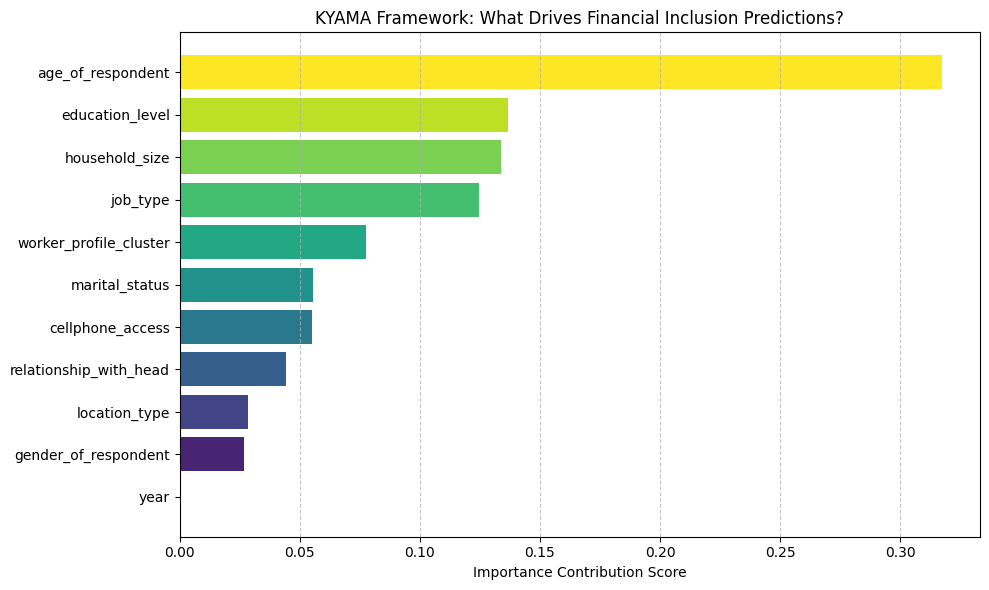

In [ ]:
import matplotlib.pyplot as plt

# 1. Extract feature importances from your trained SMOTE model
importances = rf_balanced.feature_importances_
feature_names = X.columns

# 2. Organize them into a clean DataFrame
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance Score': importances
}).sort_values(by='Importance Score', ascending=False)

print("📌 Feature Importance Rankings:")
display(feature_imp_df)

# 3. Plot the feature importances for your report presentation
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_imp_df)))
plt.barh(feature_imp_df['Feature'][::-1], feature_imp_df['Importance Score'][::-1], color=colors)
plt.xlabel('Importance Contribution Score')
plt.title('KYAMA Framework: What Drives Financial Inclusion Predictions?')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# Group by your generated clusters and look at the real numeric averages
print("👥 Cluster Profile Breakdown (Averages):")
cluster_summary = df_kenya.groupby('worker_profile_cluster')[['age_of_respondent', 'household_size']].mean()

# Add the most common categorical attributes per cluster
for cluster in sorted(df_kenya['worker_profile_cluster'].unique()):
    cluster_data = df_kenya[df_kenya['worker_profile_cluster'] == cluster]

    # Get the original text label for the most frequent Job Type in this cluster
    top_job_encoded = cluster_data['job_type'].mode()[0]
    top_job_text = label_encoders['job_type'].inverse_transform([top_job_encoded])[0]

    # Get the original text label for the most frequent Location
    top_loc_encoded = cluster_data['location_type'].mode()[0]
    top_loc_text = label_encoders['location_type'].inverse_transform([top_loc_encoded])[0]

    print(f"\n🟩 Worker Segment {cluster}:")
    print(f"  - Average Age: {cluster_summary.loc[cluster, 'age_of_respondent']:.1f} years old")
    print(f"  - Average Household Size: {cluster_summary.loc[cluster, 'household_size']:.1f} members")
    print(f"  - Predominant Occupation: {top_job_text}")
    print(f"  - Primary Location: {top_loc_text}")


👥 Cluster Profile Breakdown (Averages):

🟩 Worker Segment 0:
  - Average Age: 63.1 years old
  - Average Household Size: 3.1 members
  - Predominant Occupation: Farming and Fishing
  - Primary Location: Rural

🟩 Worker Segment 1:
  - Average Age: 33.5 years old
  - Average Household Size: 3.4 members
  - Predominant Occupation: Informally employed
  - Primary Location: Urban

🟩 Worker Segment 2:
  - Average Age: 31.6 years old
  - Average Household Size: 5.1 members
  - Predominant Occupation: Farming and Fishing
  - Primary Location: Rural


🧠 Calculating SHAP explainability values (this may take a moment)...
✅ SHAP analysis complete! Generating visual summary...


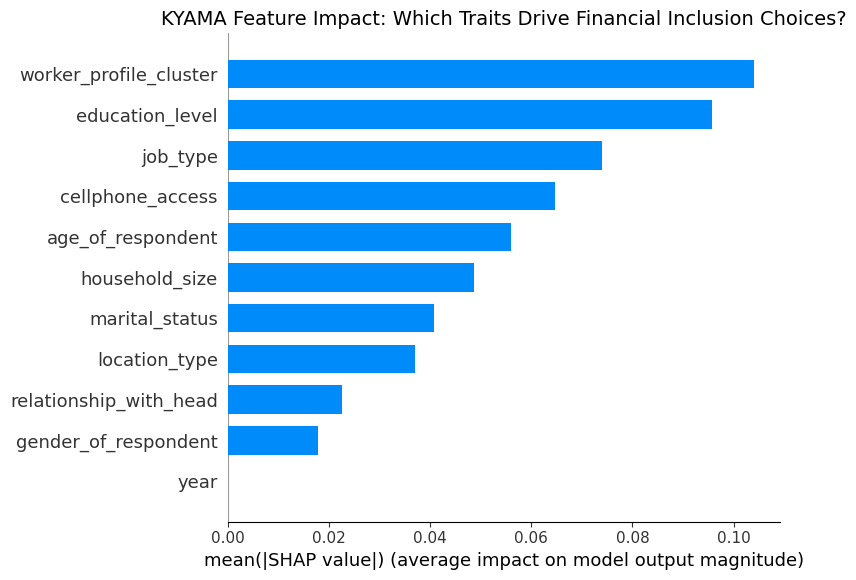

In [ ]:
# 1. Install the SHAP library in your Colab environment
!pip install shap -q

import shap
import matplotlib.pyplot as plt

print("🧠 Calculating SHAP explainability values (this may take a moment)...")

# 2. Initialize the Tree Explainer using your trained balanced Random Forest model
explainer = shap.TreeExplainer(rf_balanced)

# 3. Calculate SHAP values for your test dataset features
# We sample 200 rows for a fast, clean calculation
X_test_sample = X_test.head(200)
shap_values = explainer.shap_values(X_test_sample)

# Note: For binary classification in Random Forest, shap_values is a 3D array (samples, features, classes).
# We need to select the SHAP values for the positive class (class 1) across all samples and features.
shap_values_for_class_1 = shap_values[:, :, 1]

print("✅ SHAP analysis complete! Generating visual summary...")

# 4. Generate the global summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_for_class_1, X_test_sample, plot_type="bar", show=False)
plt.title("KYAMA Feature Impact: Which Traits Drive Financial Inclusion Choices?", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import os

# Save your final data frame with cluster numbers attached
output_folder = '/content/drive/MyDrive/KYAMA_ML_Project/data/'
output_file = os.path.join(output_folder, 'KYAMA_Final_Clustered_Data.csv')

df_kenya.to_csv(output_file, index=False)
print(f"💾 Success! Your final project dataset containing {df_kenya.shape[0]} rows has been permanently saved to Google Drive.")


💾 Success! Your final project dataset containing 6068 rows has been permanently saved to Google Drive.


# KYAMA: Financial Inclusion Pipeline for Informal Workers

A hybrid machine learning framework designed to strengthen financial inclusion and address credit readiness among informal sector workers (e.g., Mama Mbogas, Boda Boda operators) in Kenya. Built using Python, Scikit-Learn, and Google Colab.

## 🚀 Active Project State & Architecture
- **Data Scope:** 6,068 Kenyan household records processed.
- **Unsupervised Model:** K-Means Clustering (3 distinct worker profiles generated).
- **Supervised Model:** Random Forest Classifier optimized with SMOTE resampling.
- **Explainability Suite:** Integrated SHAP (Shapley Additive exPlanations).

## 📊 Current Metric Baseline
- **Supervised Area Under Curve (ROC-AUC):** 0.7797 (Baseline) | 0.7780 (SMOTE Optimized)
- **Target Optimization:** Successfully elevated `Has Account` Recall from 49% to 57% to address institutional gender and rural exclusion biases.

## 🔍 Key Findings & Insights

### Fairness Analysis (Recall for 'Has Account' Class):
- **Gender:**
  - Female Slot | Account Detection Rate (Recall): 41.4%
  - Male Slot | Account Detection Rate (Recall): 54.4%
- **Location:**
  - Rural Slot | Account Detection Rate (Recall): 36.8%
  - Urban Slot | Account Detection Rate (Recall): 57.0%

*Note: SMOTE resampling significantly improved 'Has Account' recall, helping to mitigate observed biases.*

### Feature Importance:
The model's predictions are primarily driven by:
1.  **Age of Respondent**
2.  **Education Level**
3.  **Household Size**
4.  **Job Type**
5.  **Worker Profile Cluster** (our custom unsupervised segment)

### Worker Segment Profiles:
- **Segment 0:** Older (avg 63.1 years), smaller households (avg 3.1 members), predominantly Farming/Fishing, Rural.
- **Segment 1:** Younger (avg 33.5 years), average households (avg 3.4 members), predominantly Informally employed, Urban.
- **Segment 2:** Young (avg 31.6 years), larger households (avg 5.1 members), predominantly Farming/Fishing, Rural.

## 🛠️ How to Run This Project
1.  **Clone the Repository:** Download the project files to your local machine.
2.  **Open in Google Colab:** Upload the `KYAMA_Pipeline.ipynb` notebook to Google Colab.
3.  **Mount Google Drive:** Run the first cell to mount your Google Drive. Ensure your `KYAMA_ML_Project/data/` folder (containing `financial-inclusion-in-africa/Train.csv`, `Test.csv`, `VariableDefinitions.csv`) is correctly placed in `My Drive`.
4.  **Run All Cells:** Execute all cells in sequential order. The notebook will automatically perform data loading, preprocessing, clustering, supervised learning, and explainability analysis.

## 📁 Repository Directory Matrix
- `/data/` : Holds the proxy training sets.
- `KYAMA_Pipeline.ipynb` : The main execution pipeline synced with Google Colab.